In [6]:

import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Locate the repository even if Jupyter was launched from a different folder.
current_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "backend").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing backend/")

# repo_root exposes `backend`; backend/ exposes the legacy `config` and
# `scripts` imports still used internally by some modules.
for import_root in (repo_root, repo_root / "backend"):
    import_root = str(import_root)
    if import_root not in sys.path:
        sys.path.insert(0, import_root)

from backend.scripts.data_processing import Data_Processor

In [2]:
cross_border_payments = pd.read_csv("../data/cross_border_payments.csv")
trade_finance = pd.read_csv("../data/trade_finance.csv")
transactional_banking = pd.read_csv("../data/transactional_banking.csv")

Directions found: <StringArray>
['inbound', 'outbound', 'export', 'import']
Length: 4, dtype: str


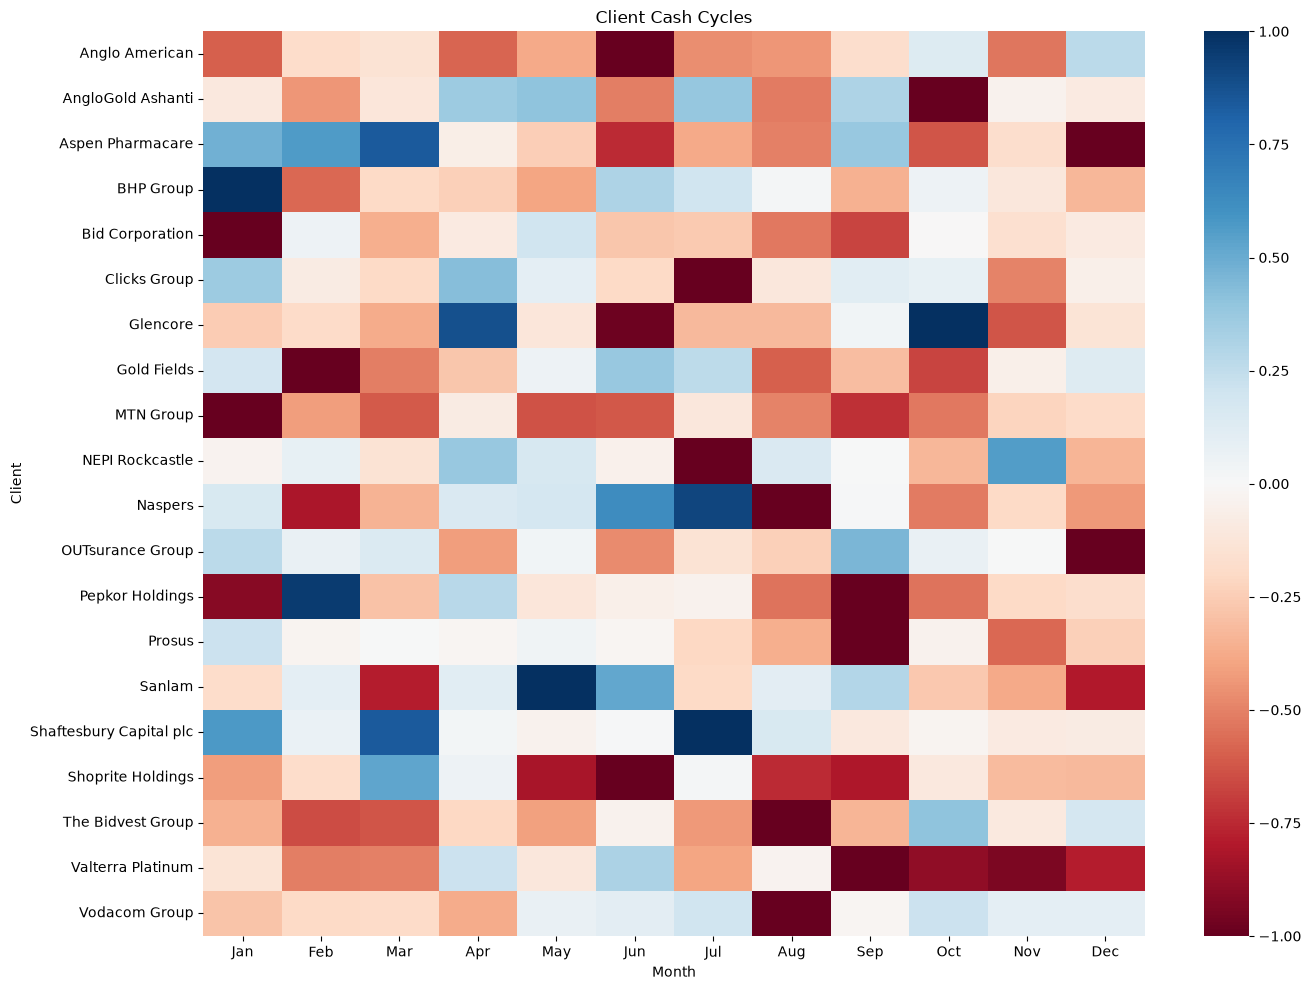

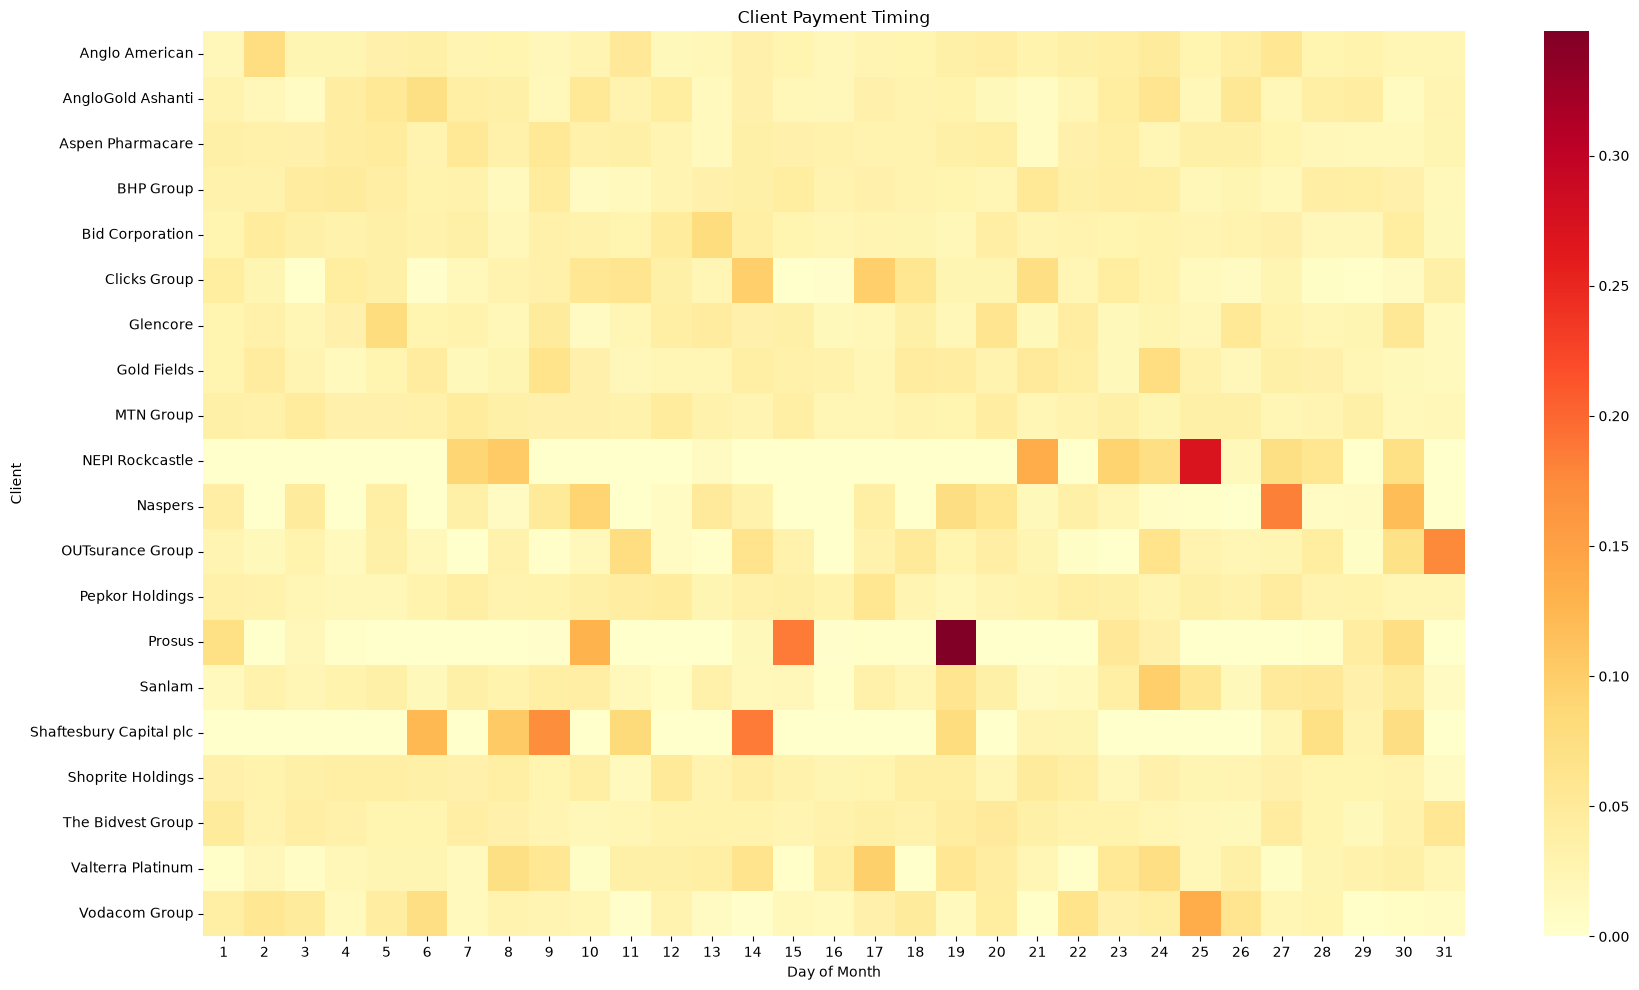

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Combine datasets
# -----------------------------
tb = transactional_banking[
    ["entity_name", "date", "direction", "amount_zar"]
].rename(columns={"amount_zar": "value_zar"})

cb = cross_border_payments[
    ["entity_name", "date", "direction", "value_zar"]
]

tf = trade_finance[
    ["entity_name", "date", "direction", "value_zar"]
]

df = pd.concat([tb, cb, tf], ignore_index=True)

df["date"] = pd.to_datetime(df["date"])
df["value_zar"] = pd.to_numeric(df["value_zar"], errors="coerce")
df["direction"] = df["direction"].astype(str).str.lower().str.strip()

print("Directions found:", df["direction"].unique())


# ============================================================
# HEATMAP 1: CASH CYCLES
# Client x Month
# ============================================================

# Treat common incoming directions as positive,
# common outgoing directions as negative.
inflows = ["credit", "inflow", "incoming", "in", "export"]
outflows = ["debit", "outflow", "outgoing", "out", "import"]

df["signed_value"] = np.where(
    df["direction"].isin(inflows),
    df["value_zar"],
    np.where(
        df["direction"].isin(outflows),
        -df["value_zar"],
        0
    )
)

df["month"] = df["date"].dt.month

cash_cycle = (
    df.groupby(["entity_name", "month"])["signed_value"]
      .mean()
      .unstack(fill_value=0)
      .reindex(columns=range(1, 13), fill_value=0)
)

# Normalise per client
cash_cycle_norm = cash_cycle.div(
    cash_cycle.abs().max(axis=1).replace(0, 1),
    axis=0
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cash_cycle_norm,
    cmap="RdBu",
    center=0,
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.title("Client Cash Cycles")
plt.xlabel("Month")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


# ============================================================
# HEATMAP 2: PAYMENT TIMING
# Client x Day of Month
# ============================================================

payments = df[
    df["direction"].isin(outflows)
].copy()

payments["day"] = payments["date"].dt.day

payment_timing = (
    payments.groupby(["entity_name", "day"])["value_zar"]
            .sum()
            .unstack(fill_value=0)
            .reindex(columns=range(1, 32), fill_value=0)
)

# Convert to proportion of each client's total outgoing payments
payment_timing_norm = payment_timing.div(
    payment_timing.sum(axis=1).replace(0, 1),
    axis=0
)

plt.figure(figsize=(18, 10))

sns.heatmap(
    payment_timing_norm,
    cmap="YlOrRd"
)

plt.title("Client Payment Timing")
plt.xlabel("Day of Month")
plt.ylabel("Client")
plt.tight_layout()
plt.show()

## Interpretation of heatmaps

From the heatmaps, it can be seen that it is plausible to want to predict cash cycles and 
payment timing based on internal data. It will be assumed that syn bank data models the full 
population. This is a bold assumption, but the best that we can do.

## Analysis of timing

In [8]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Combine datasets
# ---------------------------------------------------------

tb = transactional_banking[
    ["entity_name", "date", "direction", "amount_zar"]
].rename(columns={"amount_zar": "value_zar"})

cb = cross_border_payments[
    ["entity_name", "date", "direction", "value_zar"]
]

tf = trade_finance[
    ["entity_name", "date", "direction", "value_zar"]
]

df = pd.concat([tb, cb, tf], ignore_index=True)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["value_zar"] = pd.to_numeric(df["value_zar"], errors="coerce")
df["direction"] = df["direction"].astype(str).str.lower().str.strip()
df["day"] = df["date"].dt.day


# IMPORTANT: adjust these if your direction labels differ
INFLOW_LABELS = ["credit", "inflow", "incoming", "in", "export"]
OUTFLOW_LABELS = ["debit", "outflow", "outgoing", "out", "import"]


# ---------------------------------------------------------
# Find dominant timing for each client
# ---------------------------------------------------------

def get_timing(client_df, directions, window=3):

    x = client_df[
        client_df["direction"].isin(directions)
    ].copy()

    if len(x) == 0:
        return pd.Series({
            "peak_day": np.nan,
            "window_start": np.nan,
            "window_end": np.nan,
            "confidence": np.nan,
            "avg_value_zar": np.nan
        })

    daily = (
        x.groupby("day")["value_zar"]
         .sum()
         .reindex(range(1, 32), fill_value=0)
    )

    # Find day with highest historical value
    peak_day = int(daily.idxmax())

    window_start = max(1, peak_day - window)
    window_end = min(31, peak_day + window)

    # Proportion of total historical value occurring
    # within ±window days of peak
    total_value = daily.sum()

    window_value = daily.loc[
        window_start:window_end
    ].sum()

    confidence = (
        window_value / total_value
        if total_value > 0 else np.nan
    )

    avg_value = x["value_zar"].mean()

    return pd.Series({
        "peak_day": peak_day,
        "window_start": window_start,
        "window_end": window_end,
        "confidence": confidence,
        "avg_value_zar": avg_value
    })


# ---------------------------------------------------------
# CASH IN
# ---------------------------------------------------------

cash_in = (
    df.groupby("entity_name")
      .apply(
          lambda x: get_timing(
              x,
              INFLOW_LABELS
          ),
          include_groups=False
      )
      .add_prefix("cash_in_")
)


# ---------------------------------------------------------
# CASH OUT
# ---------------------------------------------------------

cash_out = (
    df.groupby("entity_name")
      .apply(
          lambda x: get_timing(
              x,
              OUTFLOW_LABELS
          ),
          include_groups=False
      )
      .add_prefix("cash_out_")
)


# ---------------------------------------------------------
# Final timing dataframe
# ---------------------------------------------------------

client_timings = (
    cash_in
    .join(cash_out)
    .reset_index()
)


# Make confidence easier to read
client_timings["cash_in_confidence"] = (
    client_timings["cash_in_confidence"] * 100
)

client_timings["cash_out_confidence"] = (
    client_timings["cash_out_confidence"] * 100
)


client_timings

,entity_name,cash_in_peak_day,cash_in_window_start,cash_in_window_end,cash_in_confidence,cash_in_avg_value_zar,cash_out_peak_day,cash_out_window_start,cash_out_window_end,cash_out_confidence,cash_out_avg_value_zar
0,Anglo American,22.0,19.0,25.0,25.529821,2.022922e+06,2.0,1.0,5.0,17.845207,2.347939e+06
1,AngloGold Ashanti,19.0,16.0,22.0,27.497968,1.663568e+06,6.0,3.0,9.0,27.212713,1.595794e+06
2,Aspen Pharmacare,21.0,18.0,24.0,20.119748,1.253797e+06,9.0,6.0,12.0,27.034071,1.060230e+06
3,BHP Group,24.0,21.0,27.0,25.151461,3.221406e+06,21.0,18.0,24.0,25.053430,2.823074e+06
4,Bid Corporation,27.0,24.0,30.0,25.853995,1.967466e+06,13.0,10.0,16.0,27.939581,2.001759e+06
5,Clicks Group,9.0,6.0,12.0,19.958613,1.123105e+06,14.0,11.0,17.0,31.796077,1.202304e+06
6,Glencore,23.0,20.0,26.0,25.604178,4.467259e+06,5.0,2.0,8.0,24.983997,4.044650e+06
7,Gold Fields,8.0,5.0,11.0,28.590539,1.836273e+06,24.0,21.0,27.0,26.930895,1.770158e+06
8,MTN Group,13.0,10.0,16.0,24.303502,1.748062e+06,12.0,9.0,15.0,24.259977,1.881796e+06
9,NEPI Rockcastle,14.0,11.0,17.0,32.341951,3.792318e+05,25.0,22.0,28.0,58.761380,3.952337e+05


In [9]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# Combine datasets
# ---------------------------------------------------------

tb = transactional_banking[
    ["entity_name", "date", "direction", "amount_zar"]
].rename(columns={"amount_zar": "value_zar"})

cb = cross_border_payments[
    ["entity_name", "date", "direction", "value_zar"]
]

tf = trade_finance[
    ["entity_name", "date", "direction", "value_zar"]
]

df = pd.concat([tb, cb, tf], ignore_index=True)

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["value_zar"] = pd.to_numeric(df["value_zar"], errors="coerce")
df["direction"] = df["direction"].astype(str).str.lower().str.strip()

df["day"] = df["date"].dt.day

# Adjust if your labels differ
OUTFLOW_LABELS = [
    "debit",
    "outflow",
    "outgoing",
    "out",
    "import"
]

payments = df[
    df["direction"].isin(OUTFLOW_LABELS)
].copy()


# ---------------------------------------------------------
# Calculate payment timing per client
# ---------------------------------------------------------

def get_payment_timing(client_df, window=3):

    if client_df.empty:
        return pd.Series({
            "payment_peak_day": np.nan,
            "payment_window_start": np.nan,
            "payment_window_end": np.nan,
            "payment_confidence": np.nan,
            "average_payment_zar": np.nan,
            "median_payment_zar": np.nan
        })

    # Historical outgoing value by day-of-month
    daily = (
        client_df
        .groupby("day")["value_zar"]
        .sum()
        .reindex(range(1, 32), fill_value=0)
    )

    # Most important payment day
    peak_day = int(daily.idxmax())

    window_start = max(1, peak_day - window)
    window_end = min(31, peak_day + window)

    total_value = daily.sum()

    window_value = daily.loc[
        window_start:window_end
    ].sum()

    # Share of historical payment value in predicted window
    confidence = (
        window_value / total_value
        if total_value > 0
        else np.nan
    )

    return pd.Series({
        "payment_peak_day": peak_day,
        "payment_window_start": window_start,
        "payment_window_end": window_end,
        "payment_confidence": confidence,
        "average_payment_zar": client_df["value_zar"].mean(),
        "median_payment_zar": client_df["value_zar"].median()
    })


payment_timings = (
    payments
    .groupby("entity_name")
    .apply(
        get_payment_timing,
        include_groups=False
    )
    .reset_index()
)

# Convert confidence to percentage
payment_timings["payment_confidence"] *= 100

payment_timings

,entity_name,payment_peak_day,payment_window_start,payment_window_end,payment_confidence,average_payment_zar,median_payment_zar
0,Anglo American,2.0,1.0,5.0,17.845207,2.347939e+06,1168116.885
1,AngloGold Ashanti,6.0,3.0,9.0,27.212713,1.595794e+06,889727.040
2,Aspen Pharmacare,9.0,6.0,12.0,27.034071,1.060230e+06,580627.190
3,BHP Group,21.0,18.0,24.0,25.053430,2.823074e+06,1585934.690
4,Bid Corporation,13.0,10.0,16.0,27.939581,2.001759e+06,1029783.720
5,Clicks Group,14.0,11.0,17.0,31.796077,1.202304e+06,541844.000
6,Glencore,5.0,2.0,8.0,24.983997,4.044650e+06,2288187.720
7,Gold Fields,24.0,21.0,27.0,26.930895,1.770158e+06,868815.470
8,MTN Group,12.0,9.0,15.0,24.259977,1.881796e+06,986490.110
9,NEPI Rockcastle,25.0,22.0,28.0,58.761380,3.952337e+05,323240.110


In [11]:
import pandas as pd
import numpy as np

# ============================================================
# CONSTANTS
# ============================================================

DEFAULT_LEAD_DAYS = 30

HIGH_CONFIDENCE = 70
MEDIUM_CONFIDENCE = 45

STRATEGY_LEAD_DAYS = {
    "FX / Cross-Border": 30,
    "Liquidity Management": 14,
    "Trade Finance": 30,
    "Payments / Collections": 14,
    "General Coverage": 30
}

STRATEGY_DESCRIPTIONS = {
    "FX / Cross-Border":
        "Engage treasury regarding upcoming cross-border payments, FX execution or hedging requirements.",

    "Liquidity Management":
        "Engage treasury regarding expected cash concentration, liquidity requirements or short-term funding.",

    "Trade Finance":
        "Engage regarding letters of credit, guarantees, collections or trade-finance requirements.",

    "Payments / Collections":
        "Engage regarding payment execution, collections, reconciliation or transaction banking solutions.",

    "General Coverage":
        "Use the predicted cash event as a reason for proactive relationship engagement."
}

# Adjust these if your actual direction labels differ
INFLOW_LABELS = [
    "credit",
    "inflow",
    "incoming",
    "in",
    "export"
]

OUTFLOW_LABELS = [
    "debit",
    "outflow",
    "outgoing",
    "out",
    "import"
]


# ============================================================
# PREPARE DATA
# ============================================================

tb = transactional_banking[
    ["entity_name", "date", "direction", "amount_zar"]
].copy()

tb = tb.rename(columns={
    "amount_zar": "value_zar"
})

tb["source"] = "transactional"


cb = cross_border_payments[
    ["entity_name", "date", "direction", "value_zar"]
].copy()

cb["source"] = "cross_border"


tf = trade_finance[
    ["entity_name", "date", "direction", "value_zar"]
].copy()

tf["source"] = "trade_finance"


df = pd.concat(
    [tb, cb, tf],
    ignore_index=True
)


# ============================================================
# CLEAN DATA
# ============================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df["value_zar"] = pd.to_numeric(
    df["value_zar"],
    errors="coerce"
)

df["direction"] = (
    df["direction"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df = df.dropna(
    subset=[
        "entity_name",
        "date",
        "value_zar"
    ]
)

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year


print("Directions found:")
print(df["direction"].value_counts())


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def confidence_band(confidence):

    if pd.isna(confidence):
        return "Low"

    if confidence >= HIGH_CONFIDENCE:
        return "High"

    if confidence >= MEDIUM_CONFIDENCE:
        return "Medium"

    return "Low"


def next_occurrence_of_day(day, reference_date):
    """
    Return the next occurrence of a day-of-month.

    Example:
    If peak day = 27 and today = 16 August,
    returns 27 August.

    If peak day = 10 and today = 16 August,
    returns 10 September.
    """

    reference_date = pd.Timestamp(reference_date)

    year = reference_date.year
    month = reference_date.month

    while True:

        days_in_month = pd.Period(
            f"{year}-{month:02d}"
        ).days_in_month

        valid_day = min(
            int(day),
            days_in_month
        )

        candidate = pd.Timestamp(
            year=year,
            month=month,
            day=valid_day
        )

        if candidate >= reference_date:
            return candidate

        month += 1

        if month == 13:
            month = 1
            year += 1


def choose_strategy(client_df):
    """
    Determine which product strategy best matches
    the client's historical outgoing activity.
    """

    outgoing = client_df[
        client_df["direction"].isin(
            OUTFLOW_LABELS
        )
    ].copy()

    if outgoing.empty:
        return "General Coverage"

    source_values = (
        outgoing
        .groupby("source")["value_zar"]
        .sum()
    )

    if source_values.empty:
        return "General Coverage"

    dominant_source = source_values.idxmax()

    if dominant_source == "cross_border":
        return "FX / Cross-Border"

    if dominant_source == "trade_finance":
        return "Trade Finance"

    if dominant_source == "transactional":
        return "Payments / Collections"

    return "General Coverage"


# ============================================================
# CASH CYCLE CALCULATION
# ============================================================

def calculate_cash_cycle(client_df):

    inflows = client_df[
        client_df["direction"].isin(
            INFLOW_LABELS
        )
    ].copy()

    outflows = client_df[
        client_df["direction"].isin(
            OUTFLOW_LABELS
        )
    ].copy()


    # -------------------------
    # CASH IN
    # -------------------------

    if inflows.empty:

        cash_in_peak_day = np.nan
        cash_in_window_start = np.nan
        cash_in_window_end = np.nan
        cash_in_confidence = np.nan
        average_cash_in_zar = np.nan

    else:

        daily_in = (
            inflows
            .groupby("day")["value_zar"]
            .sum()
            .reindex(
                range(1, 32),
                fill_value=0
            )
        )

        cash_in_peak_day = int(
            daily_in.idxmax()
        )

        cash_in_window_start = max(
            1,
            cash_in_peak_day - 3
        )

        cash_in_window_end = min(
            31,
            cash_in_peak_day + 3
        )

        total_in = daily_in.sum()

        window_in = daily_in.loc[
            cash_in_window_start:
            cash_in_window_end
        ].sum()

        cash_in_confidence = (
            100 * window_in / total_in
            if total_in > 0
            else np.nan
        )

        average_cash_in_zar = (
            inflows["value_zar"].mean()
        )


    # -------------------------
    # CASH OUT
    # -------------------------

    if outflows.empty:

        cash_out_peak_day = np.nan
        cash_out_window_start = np.nan
        cash_out_window_end = np.nan
        cash_out_confidence = np.nan
        average_cash_out_zar = np.nan

    else:

        daily_out = (
            outflows
            .groupby("day")["value_zar"]
            .sum()
            .reindex(
                range(1, 32),
                fill_value=0
            )
        )

        cash_out_peak_day = int(
            daily_out.idxmax()
        )

        cash_out_window_start = max(
            1,
            cash_out_peak_day - 3
        )

        cash_out_window_end = min(
            31,
            cash_out_peak_day + 3
        )

        total_out = daily_out.sum()

        window_out = daily_out.loc[
            cash_out_window_start:
            cash_out_window_end
        ].sum()

        cash_out_confidence = (
            100 * window_out / total_out
            if total_out > 0
            else np.nan
        )

        average_cash_out_zar = (
            outflows["value_zar"].mean()
        )


    return pd.Series({

        "cash_in_peak_day":
            cash_in_peak_day,

        "cash_in_window_start":
            cash_in_window_start,

        "cash_in_window_end":
            cash_in_window_end,

        "cash_in_confidence":
            round(cash_in_confidence, 2)
            if not pd.isna(cash_in_confidence)
            else np.nan,

        "average_cash_in_zar":
            average_cash_in_zar,

        "cash_out_peak_day":
            cash_out_peak_day,

        "cash_out_window_start":
            cash_out_window_start,

        "cash_out_window_end":
            cash_out_window_end,

        "cash_out_confidence":
            round(cash_out_confidence, 2)
            if not pd.isna(cash_out_confidence)
            else np.nan,

        "average_cash_out_zar":
            average_cash_out_zar
    })


# ============================================================
# PAYMENT TIMING + ENGAGEMENT CALCULATION
# ============================================================

def calculate_client_engagement(
    client_df,
    reference_date
):

    payments = client_df[
        client_df["direction"].isin(
            OUTFLOW_LABELS
        )
    ].copy()

    if payments.empty:

        return pd.Series({

            "predicted_payment_day":
                np.nan,

            "payment_window_start_day":
                np.nan,

            "payment_window_end_day":
                np.nan,

            "predicted_payment_date":
                pd.NaT,

            "payment_confidence":
                np.nan,

            "confidence_band":
                "Low",

            "expected_payment_value_zar":
                np.nan,

            "strategy":
                "General Coverage",

            "lead_days":
                DEFAULT_LEAD_DAYS,

            "recommended_engagement_date":
                pd.NaT,

            "days_until_engagement":
                np.nan,

            "days_until_payment":
                np.nan,

            "engage_now":
                False,

            "strategy_description":
                STRATEGY_DESCRIPTIONS[
                    "General Coverage"
                ]
        })


    # ========================================================
    # FIND PAYMENT PATTERN
    # ========================================================

    daily = (
        payments
        .groupby("day")["value_zar"]
        .sum()
        .reindex(
            range(1, 32),
            fill_value=0
        )
    )

    predicted_payment_day = int(
        daily.idxmax()
    )

    payment_window_start = max(
        1,
        predicted_payment_day - 3
    )

    payment_window_end = min(
        31,
        predicted_payment_day + 3
    )


    # ========================================================
    # CONFIDENCE
    # ========================================================

    total_payment_value = daily.sum()

    payment_window_value = daily.loc[
        payment_window_start:
        payment_window_end
    ].sum()

    payment_confidence = (
        100
        * payment_window_value
        / total_payment_value
        if total_payment_value > 0
        else 0
    )


    # ========================================================
    # NEXT EXPECTED PAYMENT
    # ========================================================

    predicted_payment_date = (
        next_occurrence_of_day(
            predicted_payment_day,
            reference_date
        )
    )


    # ========================================================
    # STRATEGY
    # ========================================================

    strategy = choose_strategy(
        client_df
    )

    lead_days = (
        STRATEGY_LEAD_DAYS.get(
            strategy,
            DEFAULT_LEAD_DAYS
        )
    )


    # ========================================================
    # ENGAGEMENT DATE
    # ========================================================

    recommended_engagement_date = (
        predicted_payment_date
        - pd.Timedelta(
            days=lead_days
        )
    )


    # ========================================================
    # DAYS UNTIL EVENTS
    # ========================================================

    days_until_payment = (
        predicted_payment_date
        - reference_date
    ).days

    days_until_engagement = (
        recommended_engagement_date
        - reference_date
    ).days


    # ========================================================
    # SHOULD WE ENGAGE NOW?
    # ========================================================

    engage_now = (
        recommended_engagement_date
        <= reference_date
        <= predicted_payment_date
    )


    # ========================================================
    # EXPECTED PAYMENT VALUE
    # ========================================================

    payment_window_transactions = (
        payments[
            payments["day"].between(
                payment_window_start,
                payment_window_end
            )
        ]
    )

    expected_payment_value = (
        payment_window_transactions[
            "value_zar"
        ].mean()
    )


    return pd.Series({

        "predicted_payment_day":
            predicted_payment_day,

        "payment_window_start_day":
            payment_window_start,

        "payment_window_end_day":
            payment_window_end,

        "predicted_payment_date":
            predicted_payment_date,

        "payment_confidence":
            round(
                payment_confidence,
                2
            ),

        "confidence_band":
            confidence_band(
                payment_confidence
            ),

        "expected_payment_value_zar":
            expected_payment_value,

        "strategy":
            strategy,

        "lead_days":
            lead_days,

        "recommended_engagement_date":
            recommended_engagement_date,

        "days_until_engagement":
            days_until_engagement,

        "days_until_payment":
            days_until_payment,

        "engage_now":
            engage_now,

        "strategy_description":
            STRATEGY_DESCRIPTIONS[
                strategy
            ]
    })


# ============================================================
# REFERENCE DATE
# ============================================================

REFERENCE_DATE = (
    pd.Timestamp.today()
    .normalize()
)


# ============================================================
# CREATE CASH CYCLE DATAFRAME
# ============================================================

cash_cycles = (
    df
    .groupby("entity_name")
    .apply(
        calculate_cash_cycle,
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# CREATE PAYMENT / ENGAGEMENT DATAFRAME
# ============================================================

optimal_engagement = (
    df
    .groupby("entity_name")
    .apply(
        calculate_client_engagement,
        reference_date=REFERENCE_DATE,
        include_groups=False
    )
    .reset_index()
)


# ============================================================
# ADD ENGAGEMENT PRIORITY
# ============================================================

def engagement_priority(row):

    if (
        row["confidence_band"] == "High"
        and row["engage_now"]
    ):
        return "Immediate"

    if row["confidence_band"] == "High":
        return "High"

    if row["confidence_band"] == "Medium":
        return "Medium"

    return "Low"


optimal_engagement[
    "engagement_priority"
] = optimal_engagement.apply(
    engagement_priority,
    axis=1
)


# ============================================================
# SORT BY PRIORITY
# ============================================================

priority_order = {
    "Immediate": 0,
    "High": 1,
    "Medium": 2,
    "Low": 3
}

optimal_engagement[
    "_priority_order"
] = (
    optimal_engagement[
        "engagement_priority"
    ]
    .map(priority_order)
)

optimal_engagement = (
    optimal_engagement
    .sort_values(
        [
            "_priority_order",
            "recommended_engagement_date"
        ]
    )
    .drop(
        columns="_priority_order"
    )
    .reset_index(drop=True)
)


# ============================================================
# COMBINE EVERYTHING INTO FINAL LLM DATAFRAME
# ============================================================

client_timing_intelligence = (
    optimal_engagement
    .merge(
        cash_cycles,
        on="entity_name",
        how="left"
    )
)


# ============================================================
# ADD HUMAN-READABLE TIMING STRINGS
# ============================================================

client_timing_intelligence[
    "cash_in_window"
] = (
    client_timing_intelligence[
        "cash_in_window_start"
    ]
    .fillna(0)
    .astype(int)
    .astype(str)
    +
    "-"
    +
    client_timing_intelligence[
        "cash_in_window_end"
    ]
    .fillna(0)
    .astype(int)
    .astype(str)
)

client_timing_intelligence[
    "cash_out_window"
] = (
    client_timing_intelligence[
        "cash_out_window_start"
    ]
    .fillna(0)
    .astype(int)
    .astype(str)
    +
    "-"
    +
    client_timing_intelligence[
        "cash_out_window_end"
    ]
    .fillna(0)
    .astype(int)
    .astype(str)
)

client_timing_intelligence[
    "payment_window"
] = (
    client_timing_intelligence[
        "payment_window_start_day"
    ]
    .fillna(0)
    .astype(int)
    .astype(str)
    +
    "-"
    +
    client_timing_intelligence[
        "payment_window_end_day"
    ]
    .fillna(0)
    .astype(int)
    .astype(str)
)


# ============================================================
# FINAL OUTPUT
# ============================================================

client_timing_intelligence

Directions found:
direction
inbound     1582797
outbound    1461195
import        11294
export         9009
Name: count, dtype: int64


,entity_name,predicted_payment_day,payment_window_start_day,payment_window_end_day,predicted_payment_date,payment_confidence,confidence_band,expected_payment_value_zar,strategy,lead_days,...,cash_in_confidence,average_cash_in_zar,cash_out_peak_day,cash_out_window_start,cash_out_window_end,cash_out_confidence,average_cash_out_zar,cash_in_window,cash_out_window,payment_window
0,NEPI Rockcastle,25,22,28,2026-08-25,58.76,Medium,4.257821e+05,Trade Finance,30,...,32.34,3.792318e+05,25.0,22.0,28.0,58.76,3.952337e+05,11-17,22-28,22-28
1,Pepkor Holdings,17,14,20,2026-08-17,23.22,Low,1.355468e+06,Trade Finance,30,...,22.51,1.500067e+06,17.0,14.0,20.0,23.22,1.382196e+06,9-15,14-20,14-20
2,Valterra Platinum,17,14,20,2026-08-17,30.19,Low,2.519136e+06,Trade Finance,30,...,27.01,1.558145e+06,17.0,14.0,20.0,30.19,1.738612e+06,27-31,14-20,14-20
3,Prosus,19,16,22,2026-08-19,35.99,Low,6.051390e+06,Trade Finance,30,...,74.71,1.291043e+06,19.0,16.0,22.0,35.99,3.362636e+06,7-13,16-22,16-22
4,BHP Group,21,18,24,2026-08-21,25.05,Low,3.070617e+06,Trade Finance,30,...,25.15,3.221406e+06,21.0,18.0,24.0,25.05,2.823074e+06,21-27,18-24,18-24
5,Gold Fields,24,21,27,2026-08-24,26.93,Low,2.149347e+06,Trade Finance,30,...,28.59,1.836273e+06,24.0,21.0,27.0,26.93,1.770158e+06,5-11,21-27,21-27
6,Sanlam,24,21,27,2026-08-24,29.00,Low,2.040226e+06,Trade Finance,30,...,24.40,1.778834e+06,24.0,21.0,27.0,29.00,1.468585e+06,25-31,21-27,21-27
7,Vodacom Group,25,22,28,2026-08-25,38.48,Low,2.445176e+06,Trade Finance,30,...,32.25,1.634941e+06,25.0,22.0,28.0,38.48,1.756773e+06,4-10,22-28,22-28
8,Naspers,27,24,30,2026-08-27,33.63,Low,2.689019e+06,Trade Finance,30,...,29.21,1.548843e+06,27.0,24.0,30.0,33.63,1.468676e+06,1-5,24-30,24-30
9,OUTsurance Group,31,28,31,2026-08-31,29.46,Low,2.410773e+06,Trade Finance,30,...,32.97,9.658223e+05,31.0,28.0,31.0,29.46,1.134464e+06,11-17,28-31,28-31
